In [ ]:
from langgraph.graph import StateGraph,START , END
from typing import TypedDict , Literal


In [3]:
class QuadState(TypedDict):
    a:int 
    b:int 
    c:int 
    d:float
    equation: str
    result :str
    

In [23]:
def show_equation(state: QuadState):
   equation=f"{state['a']}x^2 + {state['b']}x + {state['c']}"
   return{"equation":equation}

def calculate_discriminant(state: QuadState):
    dis=state['b']**2-4*state['a']*state['c']
    return {"d":dis}

def  calculate_real_roots(state:QuadState):
    x1= (-state['b']+state['d']**0.5)/(2*state['a'])
    x2= (-state['b']-state['d']**0.5)/(2*state['a'])
    result=f"The real roots are x1={x1} and x2={x2}"
    return {"result":result}
def calculate_repeated_roots(state:QuadState):
    x= -state['b']/(2*state['a'])
    result=f"The repeated root is x={x}"
    return {"result":result}
def calculate_no_real_roots(state:QuadState):
    return{"result":"There are no real roots"}
def check_condition(state:QuadState)-> Literal['calculate_real_roots', 'calculate_repeated_roots', 'calculate_no_real_roots']:
     if state['d'] > 0:
        return 'calculate_real_roots'
     elif state['d'] == 0:
        return 'calculate_repeated_roots'
     else:
        return 'calculate_no_real_roots'


In [26]:
graph = StateGraph(QuadState)
graph.add_node("Equation", show_equation)
graph.add_node("Discriminant",calculate_discriminant)
graph.add_node("RealRoots",calculate_real_roots)
graph.add_node("RepeatedRoots",calculate_repeated_roots)
graph.add_node("NoRealRoots",calculate_no_real_roots)
graph.add_edge(START,"Equation")
graph.add_edge("Equation","Discriminant")
graph.add_conditional_edges(
    "Discriminant",
    check_condition, 
    {
        "calculate_real_roots": "RealRoots",       
        "calculate_repeated_roots": "RepeatedRoots", 
        "calculate_no_real_roots": "NoRealRoots"     
    }
)
graph.add_edge("RealRoots",END)
graph.add_edge("RepeatedRoots",END)
graph.add_edge("NoRealRoots",END)
workflow=graph.compile()
workflow.invoke({"a": 1, "b": -5, "c": 6})

{'a': 1,
 'b': -5,
 'c': 6,
 'd': 1,
 'equation': '1x^2 + -5x + 6',
 'result': 'The real roots are x1=3.0 and x2=2.0'}

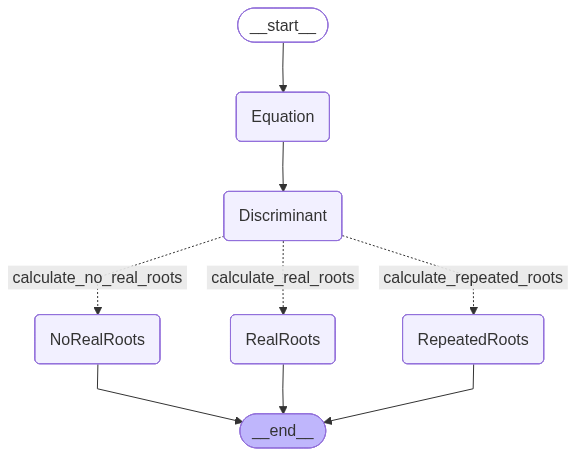

In [27]:
workflow